# 🔗 Late Fusion Training - Optimized for AMD GPU

Kombinasi prediksi dari CNN dan Landmark models dengan weight optimization untuk performa terbaik.

## 1. 📚 Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
import os
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. 🎮 AMD GPU Setup

In [2]:
def setup_amd_gpu():
    """Setup AMD GPU with DirectML for optimal performance"""
    print("🎮 Setting up AMD GPU for Late Fusion...")
    
    try:
        gpu_devices = tf.config.list_physical_devices('GPU')
        dml_devices = tf.config.list_physical_devices('DML')
        total_devices = len(gpu_devices) + len(dml_devices)
        
        if total_devices > 0:
            print(f"✅ Found {total_devices} GPU device(s)")
            
            # Configure GPU memory growth
            for gpu in gpu_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("✅ GPU memory growth enabled")
            
            return True, total_devices
        else:
            print("⚠️ No GPU detected, using CPU")
            return False, 0
    except Exception as e:
        print(f"⚠️ GPU setup failed: {e}")
        return False, 0

# Setup GPU
gpu_available, num_gpus = setup_amd_gpu()

🎮 Setting up AMD GPU for Late Fusion...
✅ Found 2 GPU device(s)
✅ GPU memory growth enabled


## 3. ⚙️ Konfigurasi Paths

In [3]:
# Paths and configurations
BASE_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/data/'
MODEL_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/models/'

# Batch size for inference
BATCH_SIZE = 64 if gpu_available else 32

print(f"🔗 Late Fusion using {'GPU' if gpu_available else 'CPU'} inference")
print(f"📊 Batch Size: {BATCH_SIZE}")

🔗 Late Fusion using GPU inference
📊 Batch Size: 64


## 4. 📁 Load Test Data

In [4]:
print("📁 Loading test data...")

try:
    X_test_images = np.load(BASE_PATH + 'images/X_test_images.npy')
    X_test_landmarks = np.load(BASE_PATH + 'landmarks/X_test_landmarks.npy')
    y_test = np.load(BASE_PATH + 'images/y_test_images.npy')
    
    print(f"✅ Test data loaded successfully!")
    print(f"Test samples: {X_test_images.shape[0]:,}")
    print(f"Image shape: {X_test_images.shape[1:]}")
    print(f"Landmark features: {X_test_landmarks.shape[1]}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit(1)

📁 Loading test data...
✅ Test data loaded successfully!
Test samples: 43
Image shape: (224, 224, 3)
Landmark features: 200


## 5. 🏷️ Load Label Mapping

In [5]:
print("🏷️ Loading label mapping...")

try:
    with open(MODEL_PATH + 'label_map.pkl', 'rb') as f:
        label_map = pickle.load(f)
    
    num_classes = len(label_map)
    target_names = list(label_map.keys())
    
    print(f"Classes: {target_names}")
    print(f"Number of classes: {num_classes}")
    
except FileNotFoundError:
    print("❌ Label mapping not found! Please train CNN model first.")
    exit(1)

# Convert labels
y_test_num = np.array([label_map[label] for label in y_test])
y_true = y_test_num

print("✅ Label preprocessing completed")

🏷️ Loading label mapping...
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
✅ Label preprocessing completed


## 6. 🔄 Load Trained Models

In [6]:
print("🔄 Loading trained models...")

try:
    # Load CNN model
    print("📱 Loading CNN model...")
    cnn_model = load_model(MODEL_PATH + 'cnn_model_best.h5')
    print(f"✅ CNN model loaded: {cnn_model.count_params():,} parameters")
    
    # Load Landmark model
    print("🎯 Loading Landmark model...")
    landmark_model = load_model(MODEL_PATH + 'landmark_model_best.h5')
    print(f"✅ Landmark model loaded: {landmark_model.count_params():,} parameters")
    
except FileNotFoundError as e:
    print(f"❌ Error loading models: {e}")
    print("💡 Please train individual models first (CNN and Landmark)")
    exit(1)

🔄 Loading trained models...
📱 Loading CNN model...
✅ CNN model loaded: 27,002,919 parameters
🎯 Loading Landmark model...
✅ Landmark model loaded: 279,687 parameters


## 7. 🔗 Late Fusion Functions

In [7]:
def late_fusion_weighted(cnn_probs, landmark_probs, weight_cnn=0.6):
    """
    Combine predictions from CNN and Landmark models with weighting
    
    Args:
        cnn_probs: Probability predictions from CNN model
        landmark_probs: Probability predictions from Landmark model
        weight_cnn: Weight for CNN model (0-1)
        
    Returns:
        Array of combined probabilities
    """
    weight_landmark = 1 - weight_cnn
    fused_probs = (weight_cnn * cnn_probs) + (weight_landmark * landmark_probs)
    return fused_probs

def evaluate_fusion_performance(cnn_probs, landmark_probs, y_true, weights):
    """Evaluate fusion performance across different weight combinations"""
    
    results = []
    
    for weight_cnn in weights:
        # Fusion dengan bobot tertentu
        fused_probs = late_fusion_weighted(cnn_probs, landmark_probs, weight_cnn)
        y_pred_fused = np.argmax(fused_probs, axis=1)
        
        # Hitung akurasi
        accuracy = np.mean(y_pred_fused == y_true)
        results.append((weight_cnn, accuracy))
        
        print(f"CNN Weight: {weight_cnn:.1f}, Landmark Weight: {1-weight_cnn:.1f}, Accuracy: {accuracy:.4f}")

    return results

## 8. 🚀 GPU-Optimized Inference

In [8]:
print("🚀 Running GPU-optimized inference...")

# Get predictions from both models
device_context = '/GPU:0' if gpu_available else '/CPU:0'

with tf.device(device_context):
    print("📱 Getting CNN predictions...")
    start_time = time.time()
    cnn_probs = cnn_model.predict(X_test_images, batch_size=BATCH_SIZE, verbose=1)
    cnn_time = time.time() - start_time
    print(f"   ⏱️ CNN inference time: {cnn_time:.2f}s")
    
    print("🎯 Getting Landmark predictions...")
    start_time = time.time()
    landmark_probs = landmark_model.predict(X_test_landmarks, batch_size=BATCH_SIZE, verbose=1)
    landmark_time = time.time() - start_time
    print(f"   ⏱️ Landmark inference time: {landmark_time:.2f}s")

# Individual model accuracies
cnn_pred = np.argmax(cnn_probs, axis=1)
landmark_pred = np.argmax(landmark_probs, axis=1)

cnn_accuracy = accuracy_score(y_true, cnn_pred)
landmark_accuracy = accuracy_score(y_true, landmark_pred)

print(f"\n📊 Individual Model Performance:")
print(f"   CNN Only: {cnn_accuracy:.4f}")
print(f"   Landmark Only: {landmark_accuracy:.4f}")

🚀 Running GPU-optimized inference...
📱 Getting CNN predictions...
1/1 [==============================] - 1s 1s/step
   ⏱️ CNN inference time: 1.57s
🎯 Getting Landmark predictions...
1/1 [==============================] - 0s 83ms/step
   ⏱️ Landmark inference time: 0.11s

📊 Individual Model Performance:
   CNN Only: 0.1628
   Landmark Only: 0.1628


## 9. ⚖️ Weight Optimization

In [9]:
print("\n⚖️ Optimizing fusion weights...")

# Test different weight combinations
weights = np.arange(0.0, 1.1, 0.1)  # From 0.0 to 1.0 in 0.1 steps
fusion_results = evaluate_fusion_performance(cnn_probs, landmark_probs, y_true, weights)

# Find best weight combination
best_weight_cnn, best_accuracy = max(fusion_results, key=lambda x: x[1])
best_weight_landmark = 1 - best_weight_cnn

print(f"\n🏆 BEST FUSION CONFIGURATION:")
print(f"   Best CNN Weight: {best_weight_cnn:.1f}")
print(f"   Best Landmark Weight: {best_weight_landmark:.1f}")
print(f"   Best Fusion Accuracy: {best_accuracy:.4f}")

# Calculate improvement
improvement = best_accuracy - max(cnn_accuracy, landmark_accuracy)
print(f"   Improvement over best individual: {improvement:.4f} ({improvement*100:.2f}%)")


⚖️ Optimizing fusion weights...
CNN Weight: 0.0, Landmark Weight: 1.0, Accuracy: 0.1628
CNN Weight: 0.1, Landmark Weight: 0.9, Accuracy: 0.1860
CNN Weight: 0.2, Landmark Weight: 0.8, Accuracy: 0.1860
CNN Weight: 0.3, Landmark Weight: 0.7, Accuracy: 0.1860
CNN Weight: 0.4, Landmark Weight: 0.6, Accuracy: 0.1860
CNN Weight: 0.5, Landmark Weight: 0.5, Accuracy: 0.1860
CNN Weight: 0.6, Landmark Weight: 0.4, Accuracy: 0.2093
CNN Weight: 0.7, Landmark Weight: 0.3, Accuracy: 0.1860
CNN Weight: 0.8, Landmark Weight: 0.2, Accuracy: 0.1395
CNN Weight: 0.9, Landmark Weight: 0.1, Accuracy: 0.1628
CNN Weight: 1.0, Landmark Weight: 0.0, Accuracy: 0.1628

🏆 BEST FUSION CONFIGURATION:
   Best CNN Weight: 0.6
   Best Landmark Weight: 0.4
   Best Fusion Accuracy: 0.2093
   Improvement over best individual: 0.0465 (4.65%)


## 10. 🔗 Final Fusion with Best Weights

In [10]:
print("\n🔗 Final fusion with optimal weights...")

# Apply best fusion
final_fused_probs = late_fusion_weighted(cnn_probs, landmark_probs, best_weight_cnn)
y_pred_fused = np.argmax(final_fused_probs, axis=1)

# Detailed evaluation
print("\n📈 Late Fusion Classification Report:")
print(classification_report(y_true, y_pred_fused, target_names=target_names))


🔗 Final fusion with optimal weights...

📈 Late Fusion Classification Report:
              precision    recall  f1-score   support

       angry       0.14      0.50      0.21         6
     disgust       0.00      0.00      0.00         6
        fear       0.00      0.00      0.00         7
       happy       0.00      0.00      0.00         6
     neutral       0.00      0.00      0.00         6
         sad       0.00      0.00      0.00         6
    surprise       0.29      1.00      0.44         6

    accuracy                           0.21        43
   macro avg       0.06      0.21      0.09        43
weighted avg       0.06      0.21      0.09        43



c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_

## 11. 📊 Weight Optimization Visualization

📊 Creating weight optimization visualization...


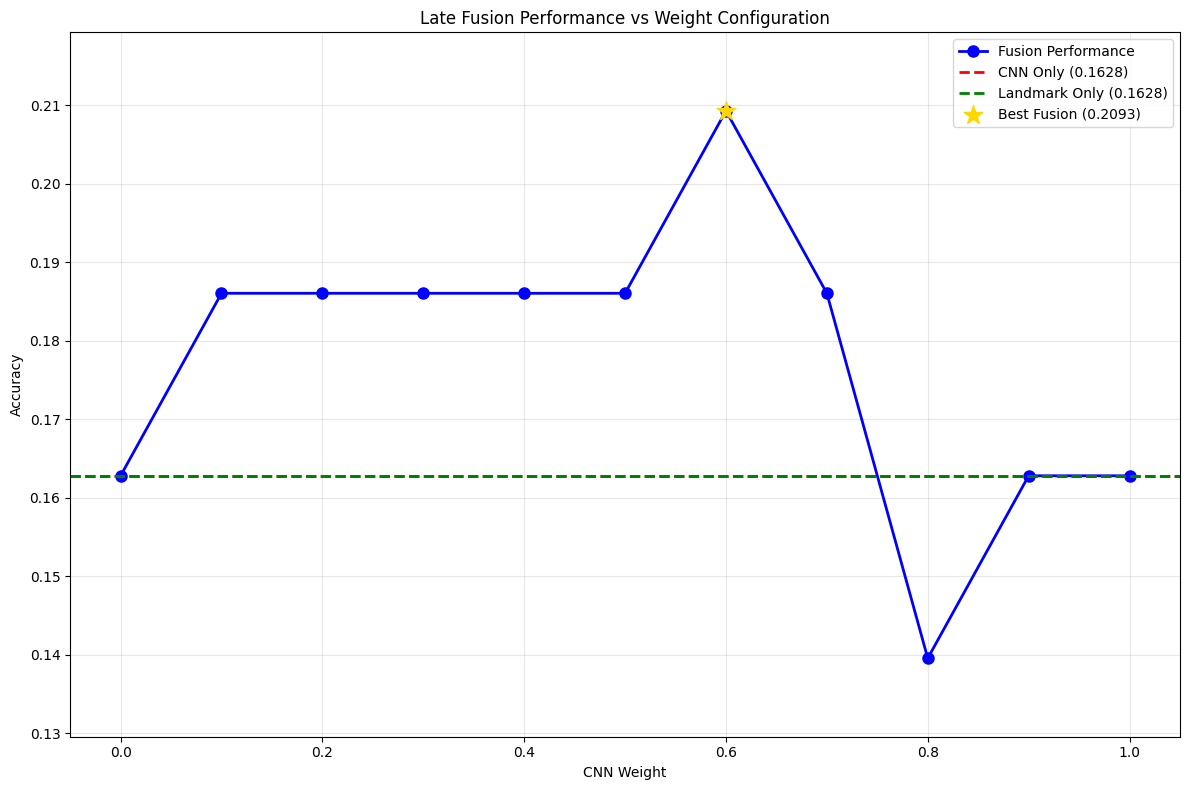

In [11]:
print("📊 Creating weight optimization visualization...")

# Weight optimization plot
plt.figure(figsize=(12, 8))

weights_list, accuracies_list = zip(*fusion_results)
plt.plot(weights_list, accuracies_list, 'bo-', linewidth=2, markersize=8, label='Fusion Performance')
plt.axhline(y=cnn_accuracy, color='red', linestyle='--', linewidth=2, 
           label=f'CNN Only ({cnn_accuracy:.4f})')
plt.axhline(y=landmark_accuracy, color='green', linestyle='--', linewidth=2,
           label=f'Landmark Only ({landmark_accuracy:.4f})')

# Mark best point
plt.scatter([best_weight_cnn], [best_accuracy], color='gold', s=200, 
           marker='*', label=f'Best Fusion ({best_accuracy:.4f})', zorder=5)

plt.xlabel('CNN Weight')
plt.ylabel('Accuracy')
plt.title('Late Fusion Performance vs Weight Configuration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(min(min(accuracies_list), cnn_accuracy, landmark_accuracy) - 0.01,
         max(max(accuracies_list), cnn_accuracy, landmark_accuracy) + 0.01)

plt.tight_layout()
plt.savefig(MODEL_PATH + 'late_fusion_weight_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. 📊 Confusion Matrix

📊 Creating confusion matrix...


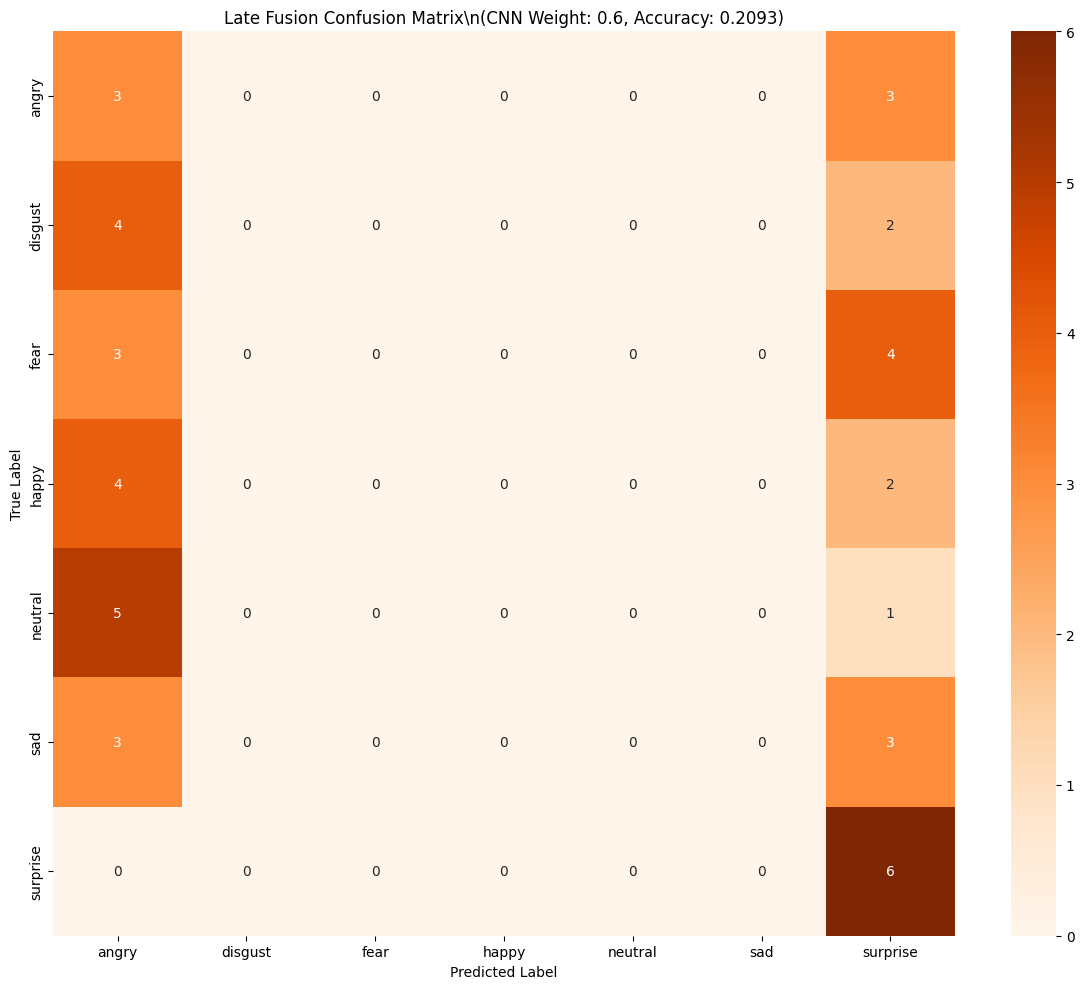

In [12]:
print("📊 Creating confusion matrix...")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_fused)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
           xticklabels=target_names, yticklabels=target_names)
plt.title(f'Late Fusion Confusion Matrix\\n(CNN Weight: {best_weight_cnn:.1f}, Accuracy: {best_accuracy:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(MODEL_PATH + 'late_fusion_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. 📊 Model Comparison

📊 Creating model comparison chart...


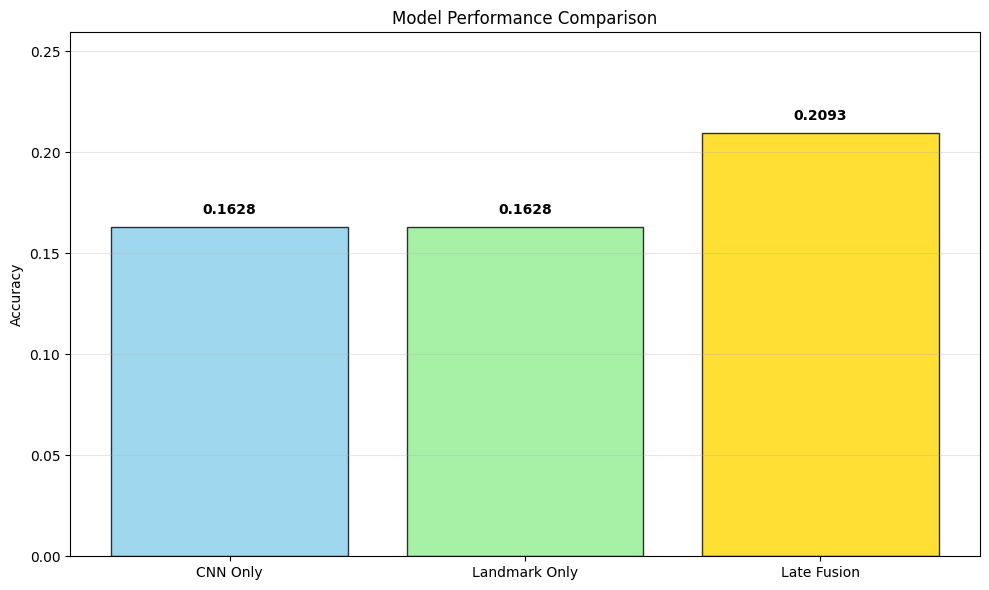

In [13]:
print("📊 Creating model comparison chart...")

# Model Comparison Bar Chart
plt.figure(figsize=(10, 6))
models = ['CNN Only', 'Landmark Only', 'Late Fusion']
accuracies = [cnn_accuracy, landmark_accuracy, best_accuracy]
colors = ['skyblue', 'lightgreen', 'gold']

bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, max(accuracies) + 0.05)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. 💾 Save Results

In [14]:
print("💾 Saving late fusion results...")

# Save fusion ensemble configuration
fusion_ensemble = {
    'best_cnn_weight': best_weight_cnn,
    'best_landmark_weight': best_weight_landmark,
    'best_accuracy': best_accuracy,
    'cnn_model_path': MODEL_PATH + 'cnn_model_best.h5',
    'landmark_model_path': MODEL_PATH + 'landmark_model_best.h5',
    'individual_accuracies': {
        'cnn': cnn_accuracy,
        'landmark': landmark_accuracy
    },
    'improvement': improvement,
    'weight_search_results': fusion_results,
    'inference_times': {
        'cnn_seconds': cnn_time,
        'landmark_seconds': landmark_time,
        'total_seconds': cnn_time + landmark_time
    },
    'device_info': f"AMD GPU ({num_gpus} device(s))" if gpu_available else "CPU"
}

with open(MODEL_PATH + 'late_fusion_ensemble.pkl', 'wb') as f:
    pickle.dump(fusion_ensemble, f)

# Save training info
training_info = {
    'model_type': 'Late_Fusion',
    'gpu_used': gpu_available,
    'num_gpus': num_gpus,
    'best_accuracy': best_accuracy,
    'best_cnn_weight': best_weight_cnn,
    'best_landmark_weight': best_weight_landmark,
    'improvement_over_individual': improvement,
    'total_inference_time': cnn_time + landmark_time,
    'device_info': f"AMD GPU ({num_gpus} device(s))" if gpu_available else "CPU"
}

with open(MODEL_PATH + 'late_fusion_training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print("✅ All results saved successfully!")

💾 Saving late fusion results...
✅ All results saved successfully!


## 15. 📝 Summary

In [15]:
print("\n" + "=" * 60)
print("🎉 LATE FUSION OPTIMIZATION COMPLETED!")
print("=" * 60)
print(f"📊 Results Summary:")
print(f"   CNN Only: {cnn_accuracy:.4f}")
print(f"   Landmark Only: {landmark_accuracy:.4f}")
print(f"   🏆 Late Fusion: {best_accuracy:.4f}")
print(f"   📈 Improvement: {improvement:.4f} ({improvement*100:.2f}%)")
print(f"\n⚖️ Optimal Weights:")
print(f"   CNN Weight: {best_weight_cnn:.1f}")
print(f"   Landmark Weight: {best_weight_landmark:.1f}")
print(f"\n🎮 Device Used: {'AMD GPU' if gpu_available else 'CPU'}")
print(f"⏱️ Total Inference Time: {cnn_time + landmark_time:.2f} seconds")
print(f"💾 Results saved to: {MODEL_PATH}")
print(f"📈 Visualizations saved to: {MODEL_PATH}")
print("\n🚀 Ready for final step: Complete Model Comparison!")
print("=" * 60)


🎉 LATE FUSION OPTIMIZATION COMPLETED!
📊 Results Summary:
   CNN Only: 0.1628
   Landmark Only: 0.1628
   🏆 Late Fusion: 0.2093
   📈 Improvement: 0.0465 (4.65%)

⚖️ Optimal Weights:
   CNN Weight: 0.6
   Landmark Weight: 0.4

🎮 Device Used: AMD GPU
⏱️ Total Inference Time: 1.67 seconds
💾 Results saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/
📈 Visualizations saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/

🚀 Ready for final step: Complete Model Comparison!
